# Notebook 2: Relationships Between Type, Task, and Goal

This notebook examines how the three final labels relate to each other:

- `type`
- `task`
- `goal`

It reflects a **behavioral structure**:
- the **kind of information** the user wants,
- the **task** they are trying to do with that information,
- and the **goal** they ultimately care about.

This notebook helps answer questions such as:

1. Do certain information types consistently support certain tasks?
2. Do certain tasks tend to serve certain goals?
3. Are there common behavioral pipelines, such as `recommendation → decision-making → purchase`?


In [52]:
import sys
print(sys.executable)
print(sys.version)

/opt/anaconda3/bin/python
3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [54]:
df= pd.read_csv('../processed_data/search_converted.csv')
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

## Type × Task relationship

This section examines whether certain kinds of information are associated with certain tasks.

In [55]:
print(df.columns)

Index(['participant_no', 'week_no', 'url', 'query', 'data', 'type', 'task',
       'goal', 'source', 'content', 'format'],
      dtype='object')


In [56]:
type_task_counts = pd.crosstab(df['type'], df['task'])
type_task_counts

task,barrier,evaluate,learn,logistics,na,option seeking,perform
type,,,,,,,
comparative,0,11,0,0,0,0,0
experiential,0,2,6,0,0,2,2
factual,0,2,137,6,0,3,0
how-to (procedural),15,0,38,0,0,0,2
how-to (psyc),4,0,2,0,0,0,0
ideas/options,5,3,23,12,0,361,6
mechanism,0,0,19,0,0,0,0
na,0,0,1,0,71,0,0
normative,0,60,22,1,0,0,0


In [57]:
type_task_rowpct = pd.crosstab(df['type'], df['task'], normalize='index')
type_task_rowpct.round(3)

task,barrier,evaluate,learn,logistics,na,option seeking,perform
type,,,,,,,
comparative,0.000,1.000,0.000,0.000,0.000,0.000,0.000
experiential,0.000,0.167,0.500,0.000,0.000,0.167,0.167
factual,0.000,0.014,0.926,0.041,0.000,0.020,0.000
how-to (procedural),0.273,0.000,0.691,0.000,0.000,0.000,0.036
how-to (psyc),0.667,0.000,0.333,0.000,0.000,0.000,0.000
ideas/options,0.012,0.007,0.056,0.029,0.000,0.880,0.015
mechanism,0.000,0.000,1.000,0.000,0.000,0.000,0.000
na,0.000,0.000,0.014,0.000,0.986,0.000,0.000
normative,0.000,0.723,0.265,0.012,0.000,0.000,0.000


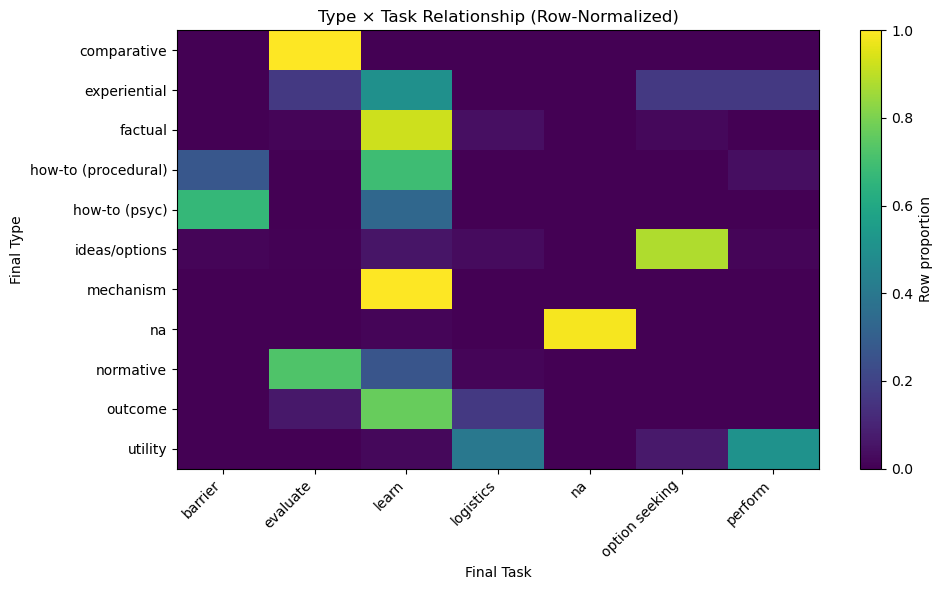

In [58]:
plt.figure(figsize=(10, 6))
plt.imshow(type_task_rowpct, aspect='auto')
plt.xticks(range(len(type_task_rowpct.columns)), type_task_rowpct.columns, rotation=45, ha='right')
plt.yticks(range(len(type_task_rowpct.index)), type_task_rowpct.index)
plt.colorbar(label='Row proportion')
plt.title('Type × Task Relationship (Row-Normalized)')
plt.xlabel('Final Task')
plt.ylabel('Final Type')
plt.tight_layout()
plt.show()

## Task × Goal relationship

In [59]:
task_goal_counts = pd.crosstab(df['task'], df['goal'])
task_goal_counts

goal,action,decision making,motivational reasoning,na,plan
task,,,,,
barrier,4,0,4,0,16
evaluate,0,69,4,0,10
learn,19,57,56,3,174
logistics,23,5,0,0,22
na,3,0,0,68,0
option seeking,12,75,4,0,278
perform,26,1,0,1,5


In [60]:
task_goal_rowpct = pd.crosstab(df['task'], df['goal'], normalize='index')
task_goal_rowpct.round(3)

goal,action,decision making,motivational reasoning,na,plan
task,,,,,
barrier,0.167,0.000,0.167,0.000,0.667
evaluate,0.000,0.831,0.048,0.000,0.120
learn,0.061,0.184,0.181,0.010,0.563
logistics,0.460,0.100,0.000,0.000,0.440
na,0.042,0.000,0.000,0.958,0.000
option seeking,0.033,0.203,0.011,0.000,0.753
perform,0.788,0.030,0.000,0.030,0.152


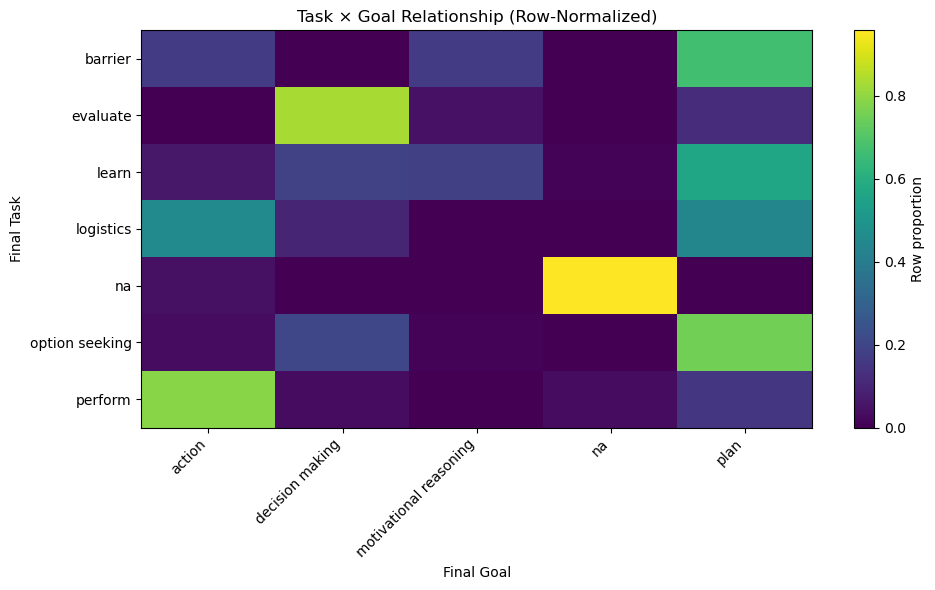

In [61]:
plt.figure(figsize=(10, 6))
plt.imshow(task_goal_rowpct, aspect='auto')
plt.xticks(range(len(task_goal_rowpct.columns)), task_goal_rowpct.columns, rotation=45, ha='right')
plt.yticks(range(len(task_goal_rowpct.index)), task_goal_rowpct.index)
plt.colorbar(label='Row proportion')
plt.title('Task × Goal Relationship (Row-Normalized)')
plt.xlabel('Final Goal')
plt.ylabel('Final Task')
plt.tight_layout()
plt.show()

## Type × Goal relationship

In [62]:
type_goal_counts = pd.crosstab(df['type'], df['goal'])
type_goal_counts

goal,action,decision making,motivational reasoning,na,plan
type,,,,,
comparative,0,10,0,0,1
experiential,5,2,1,0,4
factual,4,18,20,3,103
how-to (procedural),12,0,3,0,40
how-to (psyc),1,0,1,0,4
ideas/options,23,92,3,0,292
mechanism,0,4,5,0,10
na,3,0,0,68,1
normative,0,60,0,0,23


In [63]:
type_goal_rowpct = pd.crosstab(df['type'], df['goal'], normalize='index')
type_goal_rowpct.round(3)

goal,action,decision making,motivational reasoning,na,plan
type,,,,,
comparative,0.000,0.909,0.000,0.000,0.091
experiential,0.417,0.167,0.083,0.000,0.333
factual,0.027,0.122,0.135,0.020,0.696
how-to (procedural),0.218,0.000,0.055,0.000,0.727
how-to (psyc),0.167,0.000,0.167,0.000,0.667
ideas/options,0.056,0.224,0.007,0.000,0.712
mechanism,0.000,0.211,0.263,0.000,0.526
na,0.042,0.000,0.000,0.944,0.014
normative,0.000,0.723,0.000,0.000,0.277


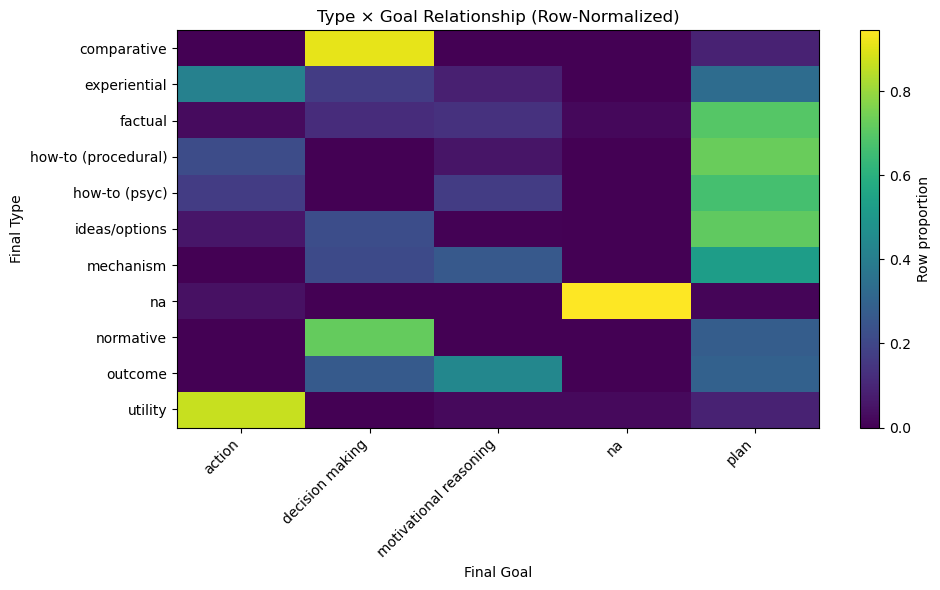

In [64]:
plt.figure(figsize=(10, 6))
plt.imshow(type_goal_rowpct, aspect='auto')
plt.xticks(range(len(type_goal_rowpct.columns)), type_goal_rowpct.columns, rotation=45, ha='right')
plt.yticks(range(len(type_goal_rowpct.index)), type_goal_rowpct.index)
plt.colorbar(label='Row proportion')
plt.title('Type × Goal Relationship (Row-Normalized)')
plt.xlabel('Final Goal')
plt.ylabel('Final Type')
plt.tight_layout()
plt.show()

## Full behavioral pipeline

Now we combine all three labels into a single pipeline. A query is often more interpretable as a **sequence** than as three separate labels.


In [65]:
df['pipeline'] = (
    df['type'].astype(str) + ' → ' +
    df['task'].astype(str) + ' → ' +
    df['goal'].astype(str)
)

pipeline_counts = df['pipeline'].value_counts().reset_index()
pipeline_counts.columns = ['pipeline', 'count']
pipeline_counts['percent'] = pipeline_counts['count'] / len(df) * 100
pipeline_counts.head(20)

,pipeline,count,percent
0,ideas/options → option seeking → plan,274,29.056204
1,factual → learn → plan,96,10.180276
2,ideas/options → option seeking → decision making,75,7.953340
3,na → na → na,68,7.211029
4,normative → evaluate → decision making,55,5.832450
5,outcome → learn → motivational reasoning,31,3.287381
6,how-to (procedural) → learn → plan,28,2.969247
7,outcome → learn → decision making,21,2.226935
8,factual → learn → motivational reasoning,20,2.120891
9,utility → perform → action,19,2.014846


### Three-column view of the most common full pipelines


In [66]:
top_full_pipelines = (
    df.groupby(['type', 'task', 'goal'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

top_full_pipelines['percent'] = top_full_pipelines['count'] / len(df) * 100
top_full_pipelines.head(20)

,type,task,goal,count,percent
40,ideas/options,option seeking,plan,274,29.056204
13,factual,learn,plan,96,10.180276
38,ideas/options,option seeking,decision making,75,7.953340
48,na,na,na,68,7.211029
49,normative,evaluate,decision making,55,5.832450
57,outcome,learn,motivational reasoning,31,3.287381
21,how-to (procedural),learn,plan,28,2.969247
56,outcome,learn,decision making,21,2.226935
11,factual,learn,motivational reasoning,20,2.120891
64,utility,perform,action,19,2.014846


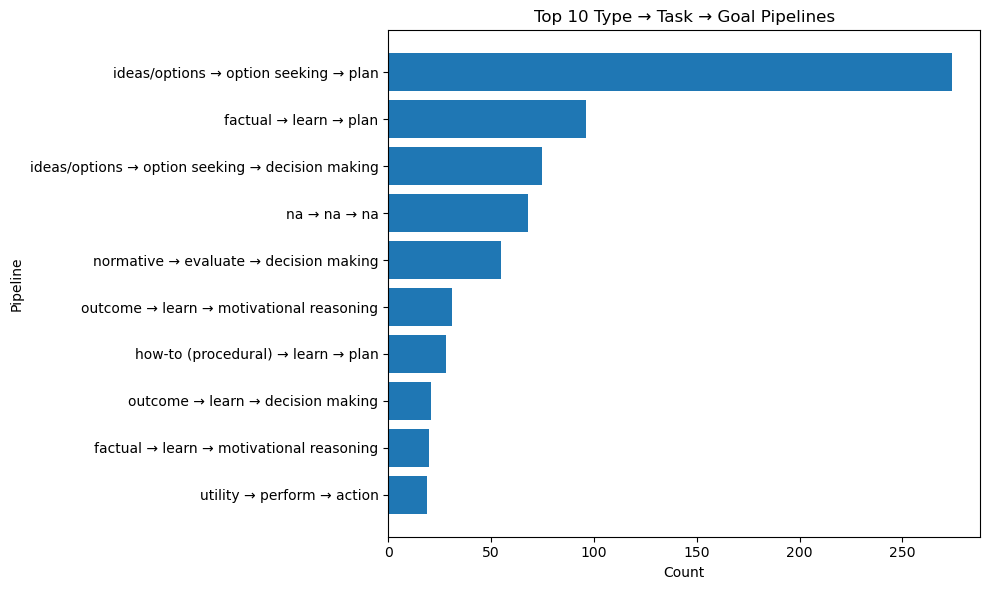

In [67]:
top_pipelines = pipeline_counts.head(10).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_pipelines['pipeline'], top_pipelines['count'])
plt.title('Top 10 Type → Task → Goal Pipelines')
plt.xlabel('Count')
plt.ylabel('Pipeline')
plt.tight_layout()
plt.show()

## 8. Most common pairwise combinations

Besides the full pipeline, it is also useful to identify the most common two-way combinations.

Why this matters:
- Two-way combinations are often easier to discuss in results sections.
- They help reveal the strongest relationships without requiring the full complexity of three labels.

In [68]:
df['type_task_pair'] = df['type'].astype(str) + ' | ' + df['task'].astype(str)
df['task_goal_pair'] = df['task'].astype(str) + ' | ' + df['goal'].astype(str)
df['type_goal_pair'] = df['type'].astype(str) + ' | ' + df['goal'].astype(str)

print('Top Type | Task pairs')
display(df['type_task_pair'].value_counts().head(10).to_frame('count'))

print('Top Task | Goal pairs')
display(df['task_goal_pair'].value_counts().head(10).to_frame('count'))

print('Top Type | Goal pairs')
display(df['type_goal_pair'].value_counts().head(10).to_frame('count'))

Top Type | Task pairs


,count
type_task_pair,
ideas/options | option seeking,361
factual | learn,137
na | na,71
outcome | learn,60
normative | evaluate,60
how-to (procedural) | learn,38
ideas/options | learn,23
utility | perform,23
normative | learn,22


Top Task | Goal pairs


,count
task_goal_pair,
option seeking | plan,278
learn | plan,174
option seeking | decision making,75
evaluate | decision making,69
na | na,68
learn | decision making,57
learn | motivational reasoning,56
perform | action,26
logistics | action,23


Top Type | Goal pairs


,count
type_goal_pair,
ideas/options | plan,292
factual | plan,103
ideas/options | decision making,92
na | na,68
normative | decision making,60
how-to (procedural) | plan,40
utility | action,39
outcome | motivational reasoning,34
normative | plan,23


##  Diversity of labels


In [69]:
print('Number of unique type labels:', df['type'].nunique())
print('Number of unique final_task labels:', df['task'].nunique())
print('Number of unique final_goal labels:', df['goal'].nunique())
print('Number of unique pipelines:', df['pipeline'].nunique())

Number of unique type labels: 11
Number of unique final_task labels: 7
Number of unique final_goal labels: 5
Number of unique pipelines: 68


## Example rows from common pipelines


In [70]:
top_pipeline_names = pipeline_counts['pipeline'].head(3).tolist()

for p in top_pipeline_names:
    print('\n' + '='*80)
    print('Pipeline:', p)
    display(
        df.loc[df['pipeline'] == p, ['participant_no', 'week_no', 'query', 'type', 'task', 'goal']]
        .head(5)
    )


Pipeline: ideas/options → option seeking → plan


,participant_no,week_no,query,type,task,goal
0,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
1,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
2,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
3,102,Week 1,vegan foods to eat that help lose weight,ideas/options,option seeking,plan
17,102,Week 1,best foods to eat as a woman,ideas/options,option seeking,plan



Pipeline: factual → learn → plan


,participant_no,week_no,query,type,task,goal
59,102,Week 2,what happens when you don't eat enough when wo...,factual,learn,plan
60,102,Week 2,what happens your bodywhen you don't eat enoug...,factual,learn,plan
62,102,Week 2,how many calories do you lose in a day,factual,learn,plan
63,102,Week 2,how many calories do you lose in a day normally,factual,learn,plan
64,102,Week 2,how many calories do you lose in a day normally,factual,learn,plan



Pipeline: ideas/options → option seeking → decision making


,participant_no,week_no,query,type,task,goal
73,102,Week 2,whats goo to eat before a yoga class,ideas/options,option seeking,decision making
194,102,Week 4,things to eat when your stomach is upset,ideas/options,option seeking,decision making
275,108,Week 1,where to hike aorund champaign,ideas/options,option seeking,decision making
276,108,Week 1,champaign walking trails safe,ideas/options,option seeking,decision making
488,109,Week 3,what is a good snack for weight loss,ideas/options,option seeking,decision making
